In [1]:
# Richardson-Lucy deconvolution for 3D microscopy stack
import numpy as np
import nrrd
from skimage.restoration import richardson_lucy

image_path = "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi.nrrd"
psf_path = "/nfs/data26/chuyu/data/20250505_181137/20250505_181137_avg_bead_volume.nrrd"

# load image and PSF
image, image_header = nrrd.read(image_path)
# exchange x and z axis
image = np.transpose(image, (2, 1, 0))
psf, psf_header = nrrd.read(psf_path)
psf = psf[::2, :, :]
psf = psf[5:-5:,:]


In [2]:
psf.shape

(21, 21, 21)

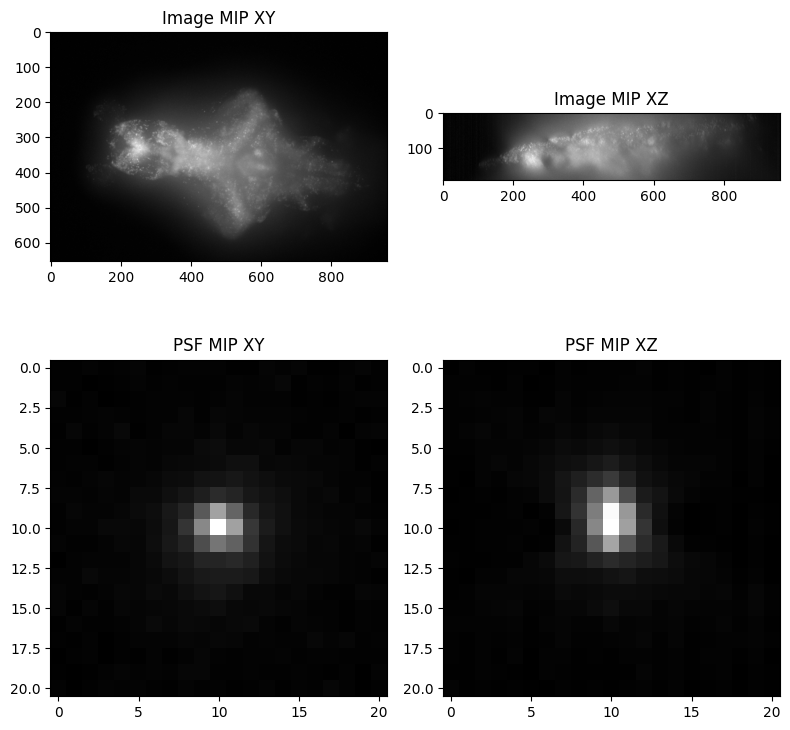

In [3]:
# plot the image and PSF as maximum intensity projections
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 2, figsize=(8, 8))
axes[0, 0].imshow(np.max(image, axis=0), cmap='gray')
axes[0, 0].set_title('Image MIP XY')
axes[0, 1].imshow(np.max(image, axis=1), cmap='gray')
axes[0, 1].set_title('Image MIP XZ')
axes[1, 0].imshow(np.max(psf, axis=0), cmap='gray')
axes[1, 0].set_title('PSF MIP XY')
axes[1, 1].imshow(np.max(psf, axis=1), cmap='gray')
axes[1, 1].set_title('PSF MIP XZ')
plt.tight_layout()
plt.show()

In [4]:

# convert to float and normalize PSF
image = image.astype(np.float32)
psf = psf.astype(np.float32)
psf_sum = np.sum(psf)
if psf_sum <= 0:
    raise ValueError("PSF sum must be positive")
psf = psf / psf_sum

# optional: scale image to avoid numerical issues
image = np.clip(image, 0, None)
orig_max = image.max()
if orig_max > 0:
    image = image / orig_max

# run Richardson-Lucy for multiple iteration counts and save each result
iteration_list = [5, 10, 20, 30, 50]
output_prefix = "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_iter_smallerpsf"

for n_iterations in iteration_list:
    deconvolved = richardson_lucy(image, psf, num_iter=n_iterations, clip=False)
    # rescale back to original intensity range
    if orig_max > 0:
        deconvolved = deconvolved * orig_max
    # switch dimension before saving
    deconvolved = np.transpose(deconvolved, (2, 1, 0))
    out_path = f"{output_prefix}{n_iterations}.nrrd"
    nrrd.write(out_path, deconvolved.astype(np.float32))
    print("Saved:", out_path)

Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_iter_smallerpsf5.nrrd
Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_iter_smallerpsf10.nrrd
Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_iter_smallerpsf20.nrrd
Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_iter_smallerpsf30.nrrd
Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_iter_smallerpsf50.nrrd


In [5]:
# Richardson-Lucy deconvolution from scratch (FFT-based)
import numpy as np
import nrrd

def _pad_psf_to_image(psf, image_shape):
    psf_padded = np.zeros(image_shape, dtype=np.float32)
    psf_shape = np.array(psf.shape)
    img_shape = np.array(image_shape)
    # center PSF in the padded array
    start = (img_shape - psf_shape) // 2
    end = start + psf_shape
    slices = tuple(slice(s, e) for s, e in zip(start, end))
    psf_padded[slices] = psf
    # shift so that center is at the origin for FFT convolution
    psf_padded = np.fft.ifftshift(psf_padded)
    return psf_padded

def _fft_convolve(image, psf_padded_fft):
    return np.fft.ifftn(np.fft.fftn(image) * psf_padded_fft).real

def richardson_lucy_fft(image, psf, num_iter=30, eps=1e-7):
    # assumes image and psf are float32 and psf is normalized
    psf_padded = _pad_psf_to_image(psf, image.shape)
    psf_fft = np.fft.fftn(psf_padded)
    # flipped PSF for the correction step
    psf_mirror = psf[::-1, ::-1, ::-1]
    psf_mirror_padded = _pad_psf_to_image(psf_mirror, image.shape)
    psf_mirror_fft = np.fft.fftn(psf_mirror_padded)

    estimate = np.full_like(image, np.maximum(image.mean(), eps))
    for _ in range(int(num_iter)):
        conv = _fft_convolve(estimate, psf_fft)
        relative_blur = image / (conv + eps)
        estimate *= _fft_convolve(relative_blur, psf_mirror_fft)
    return estimate

# run RL from scratch for multiple iteration counts and save each result
iteration_list = [5, 10, 20, 30, 50]
output_prefix_scratch = "/nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_scratch_iter_smallerpsf"

for n_iterations in iteration_list:
    deconvolved_scratch = richardson_lucy_fft(image, psf, num_iter=n_iterations, eps=1e-7)
    # rescale back to original intensity range
    if orig_max > 0:
        deconvolved_scratch = deconvolved_scratch * orig_max
    out_path = f"{output_prefix_scratch}{n_iterations}.nrrd"
    deconvolved_scratch = np.transpose(deconvolved_scratch, (2, 1, 0))
    nrrd.write(out_path, deconvolved_scratch.astype(np.float32))
    print("Saved:", out_path)

Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_scratch_iter_smallerpsf5.nrrd
Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_scratch_iter_smallerpsf10.nrrd
Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_scratch_iter_smallerpsf20.nrrd
Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_scratch_iter_smallerpsf30.nrrd
Saved: /nfs/data28/chuyu/data/20260109_095628/reference_stack_epi_RL_deconv_scratch_iter_smallerpsf50.nrrd
